# Implement folder Planck equation

In [5]:
import numpy as np

# ------------ parameters ------------------------------------------------
p_let, p_diff = 0.15, 0.10
mu_M, sigma_M = 0.3, 0.3
lam = np.log(2) + np.log1p(-p_let) + np.log1p(-p_diff)

p_let = 0.15   #→ f_let
p_aa  = 0.10   #→ f_aa
p_sil=0.75

μ_M   = 0.3
σ_M   = 0.3
C = 5.0
eps_Ag = 0.0
N_i = 2_500
N_max = 2_500
f_aa  = p_aa/(p_aa+p_sil)
f_sil = 1.0 - f_aa 

mu_M   = 0.3
sigma_M = 0.3

v = f_aa * mu_M                   # 0.03
D = f_aa * (sigma_M**2 + f_sil * mu_M**2)   # 0.01575

# ------------ grids -----------------------------------------------------
T = 60           # keep short just for demonstration
dt = 0.1
n_steps = int(T / dt)

eps_min, eps_max = -5.0, 5.0
d_eps = 0.05
eps_grid = np.arange(eps_min, eps_max + d_eps, d_eps)

# ------------ initial density ------------------------------------------
mu_i, sigma_i = 3.0, 1.5
rho = np.exp(-(eps_grid - mu_i) ** 2 / (2 * sigma_i ** 2))
rho *= N_i / (rho.sum() * d_eps)

# ------------ helpers ---------------------------------------------------
def P_Ag(eps, C_t):
    return C_t * np.exp(-eps) / (C_t * np.exp(-eps) + np.exp(-eps_Ag))

def P_T(eps, C_t, mean_eps):
    return C_t * np.exp(-eps) / (C_t * np.exp(-eps) + np.exp(-mean_eps))

Omega = 0.0

print(f"{'step':>5} {'time':>6} {'N':>10} {'Omega':>10} {'⟨Γ⟩':>10}")
# ------------------------------------------------------------------
# helper: compute flux at cell edges  (i = cell centre index)
# ------------------------------------------------------------------
def compute_flux(rho, v, D, d_eps):
    """
    Returns J_{i+1/2} on a staggered grid, length = len(rho)+1.
    Zero-flux boundary conditions: J[0] = J[-1] = 0.
    """
    J = np.zeros(rho.size + 1)

    # upwind for drift term  v*rho
    # --------------------------------------------------------------
    if v >= 0:
        J[1:-1] += v * rho[:-1]          # wind from left cell
    else:
        J[1:-1] += v * rho[1:]           # wind from right cell

    # centred diff for diffusion –(D/2) ∂_ε rho
    # --------------------------------------------------------------
    J[1:-1] -= 0.5 * D * (rho[1:] - rho[:-1]) / d_eps
    return J            # J[0]=J[-1]=0 → no net loss at boundaries

for step in range(1, n_steps + 1):
    N = rho.sum() * d_eps
    mean_eps = (rho * eps_grid).sum() * d_eps / N
    
    PAg = P_Ag(eps_grid, C)
    PT  = P_T(eps_grid, C, mean_eps)
    log_sel = np.log(PAg) + np.log(PT)
    avg_log_sel = (rho * log_sel).sum() * d_eps / N
    
    # Ω update following eq. (56)
    Omega = 0.0 if N < N_max else max(0.0, lam + avg_log_sel)
    
    Gamma = lam + log_sel - Omega
    mean_Gamma = (rho * Gamma).sum() * d_eps / N
    
    # print every step (demo)
    print(f"{step:5d} {step*dt:6.2f} {N:10.1f} {Omega:10.4f} {mean_Gamma:10.4f}")
    
    # FP update (explicit Euler)
# ------------------------------------------------------------------
# conservative FP update
# ------------------------------------------------------------------
    J = compute_flux(rho, v, D, d_eps)
    div_J = (J[1:] - J[:-1]) / d_eps      # discrete –∂_ε J

    rho += dt * (Gamma * rho - div_J)     # EXACT mass conservation

    rho = np.maximum(rho, 0.0)


 step   time          N      Omega        ⟨Γ⟩
    1   0.10     2500.0     0.0000    -1.4223
    2   0.20     2144.4     0.0000    -1.3123
    3   0.30     1863.0     0.0000    -1.2069
    4   0.40     1638.2     0.0000    -1.1075
    5   0.50     1456.7     0.0000    -1.0152
    6   0.60     1308.9     0.0000    -0.9306
    7   0.70     1187.1     0.0000    -0.8536
    8   0.80     1085.7     0.0000    -0.7842
    9   0.90     1000.6     0.0000    -0.7217
   10   1.00      928.4     0.0000    -0.6656
   11   1.10      866.6     0.0000    -0.6152
   12   1.20      813.4     0.0000    -0.5700
   13   1.30      767.1     0.0000    -0.5290
   14   1.40      726.6     0.0000    -0.4920
   15   1.50      690.9     0.0000    -0.4581
   16   1.60      659.4     0.0000    -0.4272
   17   1.70      631.3     0.0000    -0.3988
   18   1.80      606.2     0.0000    -0.3727
   19   1.90      583.6     0.0000    -0.3486
   20   2.00      563.3     0.0000    -0.3263
   21   2.10      545.0     0.0000

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def fp_density_time_series(
    # ── biological parameters ────────────────────────────────────────────
    p_let=0.15,                # lethal-mutation fraction
    p_aa=0.10,                 # affinity-affecting fraction
    p_sil=0.75,                # silent fraction  (1 − p_let − p_aa by default)
    mu_M=0.3, sigma_M=0.3,     # mean / std of affinity change Δε for aa mutations
    C=5.0,                     # (constant) antigen concentration
    eps_Ag=0.0,                # reference affinity of Ag gate
    N_i=2500, N_max=2500,      # initial & max GC population
    mu_i=3.0, sigma_i=1.5,     # initial Gaussian mean / std in ε
    p_diff = 0.10,

    # ── simulation grid & time step ──────────────────────────────────────
    eps_min=-7.0, eps_max=7.0, d_eps=0.02,
    T=60.0, dt=0.001,

    # ── output control ───────────────────────────────────────────────────
    snapshot_interval=1.0      # store every (days)
):
    """
    Returns:
        eps_grid         (len_E,)               – ε mesh
        times            (n_snap,)              – snapshot times
        rho_t_eps        (n_snap, len_E)        – density ρ(time, ε)
    """

    # ── derived constants (Eqs. 53–54) ───────────────────────────────────
    f_aa  = p_aa / (p_aa + p_sil)              # normalised among viable clones
    f_sil = 1.0 - f_aa
    v     = f_aa * mu_M
    D     = f_aa * (sigma_M**2 + f_sil * mu_M**2)
    lam   = np.log(2) + np.log(1-p_let) + np.log(1-p_diff)

    # ── ε and t grids ────────────────────────────────────────────────────
    eps_grid = np.arange(eps_min, eps_max + d_eps, d_eps)
    n_steps  = int(np.round(T / dt))
    snap_every = max(1, int(np.round(snapshot_interval / dt)))

    # ── initial density ρ(t=0, ε) ────────────────────────────────────────
    rho = np.exp(-(eps_grid - mu_i)**2 / (2 * sigma_i**2))
    rho *= N_i / (rho.sum() * d_eps)

    # store first snapshot
    snapshots = [rho.copy()]
    times     = [0.0]

    # ── helpers (vectorised) ─────────────────────────────────────────────
    def P_Ag(eps):
        return C * np.exp(-eps) / (C * np.exp(-eps) + np.exp(-eps_Ag))

    def compute_flux(r):
        J = np.zeros(r.size + 1)
        # upwind drift
        if v >= 0:
            J[1:-1] += v * r[:-1]
        else:
            J[1:-1] += v * r[1:]
        # centred diffusion
        J[1:-1] -= 0.5 * D * (r[1:] - r[:-1]) / d_eps
        return J

    # ── time integration loop ───────────────────────────────────────────
    for step in range(1, n_steps + 1):
        N         = rho.sum() * d_eps
        mean_eps  = (rho * eps_grid).sum() * d_eps / N
        P_T       = C * np.exp(-eps_grid) / (C * np.exp(-eps_grid) + np.exp(-mean_eps))
        log_sel   = np.log(P_Ag(eps_grid)) + np.log(P_T)
        avg_log   = (rho * log_sel).sum() * d_eps / N

        Omega     = 0.0 if N < N_max else max(0.0, lam + avg_log)
        Gamma     = lam + log_sel - Omega

        # conservative update
        J = compute_flux(rho)
        div_J = (J[1:] - J[:-1]) / d_eps
        rho += dt * (Gamma * rho - div_J)
        rho  = np.maximum(rho, 0.0)

        # store snapshot
        if step % snap_every == 0:
            snapshots.append(rho.copy())
            times.append(step * dt)

    rho_t_eps = np.vstack(snapshots)
    return eps_grid, np.array(times), rho_t_eps
eps_grid, times, rho_t_eps=fp_density_time_series(C=5) 
n_cols = 2
n_rows = (1 + 1) // n_cols

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols,
    figsize=(n_cols*6, n_rows*4),
    constrained_layout=True
)




: 

In [3]:
import matplotlib.pyplot as plt

# Example: your list of C values
C_list = [0.5, 1.5, 2.5, 5.0]

# Compute all results once:
results = [fp_density_time_series(C=C_val) for C_val in C_list]

# Setup 2 columns
n_cols = 2
n_rows = (len(C_list) + 1) // n_cols

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols,
    figsize=(n_cols*6, n_rows*4),
    constrained_layout=True
)

# Flatten axes for easy loop
axes = axes.flatten()

for idx, (C_val, ax) in enumerate(zip(C_list, axes)):
    eps_grid, times, rho_series = results[idx]
    im = ax.imshow(
        rho_series.T,
        origin="lower",
        aspect="auto",
        extent=[times[0], times[-1], eps_grid[0], eps_grid[-1]],
        cmap="plasma"
    )
    ax.set_title(f"ρ(t, ε) –  C = {C_val}")
    ax.set_xlabel("Time t (days)")
    ax.set_ylabel("Binding energy ε")
    fig.colorbar(im, ax=ax, label="Density ρ")

# If you have unused axes, hide them
for ax in axes[len(C_list):]:
    ax.axis("off")

plt.show()


NameError: name 'k' is not defined

# Least action

In [1]:
from __future__ import annotations
import torch
import math

In [ ]:
import torch
import numpy as np

# ---------------------------------------------------------------------
# Constants and helper functions
# ---------------------------------------------------------------------
p_let, p_diff = 0.15, 0.10
mu_M, sigma_M = 0.3, 0.3
lam = np.log(2) + np.log1p(-p_let) + np.log1p(-p_diff)

v, D  = mu_M, sigma_M**2
# option C – 60-unit horizon with finer grid
T, N = 60.0, 6000
dt   = T/N
# --- trainable "external" parameter ---------------------------------
C = torch.tensor(5.0, dtype=torch.double, requires_grad=True)  # <- θ

def Gamma(eps, C, N): 
    P_Ag = C * torch.exp(-eps) / (C * torch.exp(-eps) + torch.exp(-eps_Ag))
    P_T  = C * torch.exp(-eps) / (C * torch.exp(-eps) + torch.exp(-mean_eps))
    log_sel   = np.log(P_Ag(eps_grid)) + np.log(P_T)
    avg_log   = (rho * log_sel).sum() * d_eps / N

    Omega     = 0.0 if N < N_max else max(0.0, lam + avg_log)
    Gamma     = lam + log_sel - Omega
    return Gamma
# ---------------------------------------------------------------------
# Fixed path: ε(t) and ε̂(t) known beforehand (here: a straight line)
# ---------------------------------------------------------------------

eps_init, eps_final = 3.0, -3.
eps = torch.linspace(eps_init, eps_final, N + 1, dtype=torch.double,
                     requires_grad=True)          # we want its value, but no grad
eps_hat = torch.zeros_like(eps[:-1], requires_grad=True)      # idem

# ---------------------------------------------------------------------
# Build the mixed (Martin–Siggia–Rose) action
#    S[ε, ε̂] = Σ dt [ ε̂ ( \dot ε - v ) + D ε̂² - Γ(ε) ]
# ---------------------------------------------------------------------
eps_dot = (eps[1:] - eps[:-1]) / dt
S = dt * torch.sum(eps_hat * (eps_dot - v) + D * eps_hat**2 - Gamma(eps[:-1], C))

# ---------------------------------------------------------------------
# 1️⃣ Tell autograd to keep the graph, but
# 2️⃣ immediately zero out the unwanted gradients
# ---------------------------------------------------------------------
S.backward(retain_graph=True)

# ---- ERASE gradients flowing to ε and ε̂ ----------------------------
eps.grad.zero_()          # remove ∂S/∂ε
eps_hat.grad.zero_()      # remove ∂S/∂ε̂
# ---------------------------------------------------------------------

# Now C.grad is the only non-zero gradient.
print(f"dS/dC = {C.grad.item():.6f}")        # should be negative here

# ---------------------------------------------------------------------
# Example optimisation step on C only
# ---------------------------------------------------------------------
opt = torch.optim.SGD([C], lr=1e-2)
opt.step()
opt.zero_grad()

print(f"New C  = {C.item():.4f}")


dS/dC = 200.257336
New C  = 2.9974


dS/dC before step: 200.257336
updated C: 2.9974


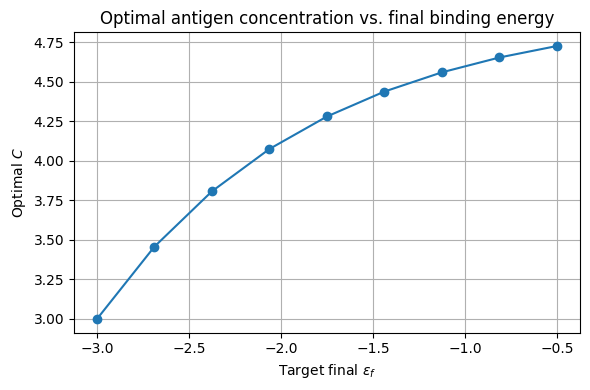

In [ ]:
import torch
import numpy as np

# ---------------------------------------------------------------------
# Constants and helper functions (unchanged)
# ---------------------------------------------------------------------
p_let, p_diff = 0.15, 0.10
mu_M, sigma_M = 0.3, 0.3
lam = np.log(2) + np.log1p(-p_let) + np.log1p(-p_diff)

v, D  = mu_M, sigma_M**2
T, N  = 60.0, 6000
dt    = T / N


# ---------------------------------------------------------------------
def Omega(N_t: torch.Tensor,
          N_max: int,
          lam: float,
          log_P_Ag_pop: torch.Tensor,
          log_P_T_pop: torch.Tensor) -> torch.Tensor:
    """
    Piece-wise definition of Ω(t).

    Args
    ----
    N_t            : current population size  (scalar tensor or float)
    N_max          : carrying capacity
    lam            : affinity-independent growth term (λ)
    log_P_Ag_pop   : ⟨log P_Ag⟩ over the population at time t
    log_P_T_pop    : ⟨log P_T⟩ over the population at time t

    Returns
    -------
    Ω(t) as a scalar tensor
    """
    below_cap = (N_t < N_max)
    omega_val = torch.where(
        below_cap,
        torch.tensor(0.0, dtype=torch.double, device=N_t.device),
        torch.maximum(
            torch.tensor(0.0, dtype=torch.double, device=N_t.device),
            lam + log_P_Ag_pop + log_P_T_pop
        )
    )
    return omega_val

# ---------------------------------------------------------------------
# Modified growth kernel Γ(t, ε)        [Eq. (55)]
# ---------------------------------------------------------------------
# ---------------------------------------------------------------------
# Growth kernel Γ(t, ε)  –  consistent with _select_Ag / _select_T
# ---------------------------------------------------------------------
def Gamma(eps: torch.Tensor,
          C_t: torch.Tensor | float,
          eps_Ag: float,
          mean_eps: torch.Tensor,
          omega_t: torch.Tensor) -> torch.Tensor:
    """
    Γ(t, ε) = λ + log P_Ag(ε) + log P_T(ε, t) − Ω(t)

    • eps:      affinity values for the (sub-)population                    (B,)
    • C_t:      antigen concentration at time t (can be a learnable param)  scalar
    • eps_Ag:   Ag-recognition threshold parameter                          float
    • mean_eps: ⟨ε⟩  of the population at time t                            scalar
    • omega_t:  Ω(t) from the carrying-capacity constraint                  scalar
    """
    # ensure tensors ----------------------------------------------------
    C_t       = torch.as_tensor(C_t,       dtype=eps.dtype, device=eps.device)
    eps_Ag_t  = torch.as_tensor(eps_Ag,    dtype=eps.dtype, device=eps.device)
    mean_eps  = torch.as_tensor(mean_eps,  dtype=eps.dtype, device=eps.device)

    # log P_Ag(ε) --------------------------------------------------------
    # P_Ag =  C e^{-ε}  /  ( C e^{-ε} + e^{-ε_Ag} )
    # ⇒ log P_Ag = log C − ε − log( C e^{-ε} + e^{-ε_Ag} )
    log_P_Ag  = torch.log(C_t) - eps - torch.log(C_t * torch.exp(-eps) +
                                                 torch.exp(-eps_Ag_t))

    # log P_T(ε,t) -------------------------------------------------------
    # P_T =  C e^{-ε}  /  ( C e^{-ε} + e^{-⟨ε⟩} )
    # use ⟨ε⟩ of the *whole* population at time t
    log_P_T   = torch.log(C_t) - eps - torch.log(C_t * torch.exp(-eps) +
                                                 torch.exp(-mean_eps))

    # Γ(t, ε) ------------------------------------------------------------
    return lam + log_P_Ag + log_P_T - omega_t

# ---------------------------------------------------------------------
# Wrapper
# ---------------------------------------------------------------------
def optimise_C_for_eps_final(epsilon_f: float,
                             lr: float = 1e-2,
                             C0: float = 5.0):
    """
    One-step SGD update on C for a fixed straight-line path ending at epsilon_f.
    Returns (dS/dC before step,  C after the step).
    """
    # --- trainable external parameter θ = C --------------------------
    C = torch.tensor(C0, dtype=torch.double, requires_grad=True)

    # --- fixed path ε(t) and ε̂(t) (verbatim from your code) ---------
    eps_init = 3.0
    eps = torch.linspace(eps_init, epsilon_f, N + 1,
                         dtype=torch.double, requires_grad=True)
    eps_hat = torch.zeros_like(eps[:-1], requires_grad=True)

    # --- build mixed action -----------------------------------------
    eps_dot = (eps[1:] - eps[:-1]) / dt
    S = dt * torch.sum(eps_hat * (eps_dot - v)
                       + D * eps_hat**2
                       - Gamma(eps[:-1], C))

    # --- backward pass & gradient cleanup ---------------------------
    S.backward(retain_graph=True)
    eps.grad.zero_()
    eps_hat.grad.zero_()

    dS_dC = C.grad.item()     # store before the update

    # --- one SGD step on C only -------------------------------------
    opt = torch.optim.SGD([C], lr=lr)
    opt.step()
    opt.zero_grad()

    C_new = C.item()
    return dS_dC, C_new


dgrad, Cstar = optimise_C_for_eps_final(epsilon_f=-3.0)
print(f"dS/dC before step: {dgrad:.6f}")
print(f"updated C: {Cstar:.4f}")

#plot 
import matplotlib.pyplot as plt
eps_f_list = np.linspace(-3.0, -0.5, 9)    # adjust range if needed
C_star_list = [optimise_C_for_eps_final(eps_f)[1] for eps_f in eps_f_list]


plt.figure(figsize=(6, 4))
plt.plot(eps_f_list, C_star_list, marker='o')
plt.xlabel(r'Target final $\varepsilon_f$')
plt.ylabel(r'Optimal $C$')
plt.title('Optimal antigen concentration vs. final binding energy')
plt.grid(True)
plt.tight_layout()
plt.show()
